# Project 1: Hybrid Merge/Insertion Sort — Analysis

This notebook drives the C++ programs in `src/` (built via `make`) as subprocesses and displays relevant plots/graphs.

- **(c-i)** comparisons vs `n` with `S` fixed, vs. theoretical `O(n log n)`
- **(c-ii)** comparisons vs `S` with `n` fixed
- **(c-iii)** empirically determining an optimal `S`
- **(d)** hybrid sort vs. plain merge sort at `n = 10,000,000`

Run with the `sc2001-lab1` conda kernel (`conda env create -f environment.yml` from the project root).

## Setup

In [5]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SRC_DIR = "src"
BINARY = f"{SRC_DIR}/benchmark"

# Build the C++ benchmark binary.
result = subprocess.run(["make", "-C", SRC_DIR], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("build failed")
print("Build OK")

make: Nothing to be done for `all'.

Build OK


## (a) Algorithm implementation: 
Implement the above hybrid algorithm. 

The algorithms have been implemented in C++ to optimize inference time.

Implemented the below functions to run the C++ files.

In [6]:
def run(algo: str, n: int, S: int = 0, seed: int = 1) -> dict:
    """Invoke the C++ benchmark binary and parse its CSV output line.

    Returns a dict with keys: algo, n, S, seed, comparisons, time_ms.
    """
    proc = subprocess.run(
        [BINARY, algo, str(n), str(S), str(seed)],
        capture_output=True, text=True,
    )
    if proc.returncode != 0:
        raise RuntimeError(f"benchmark failed for {algo=} {n=} {S=} {seed=}: {proc.stderr}")
    algo_, n_, S_, seed_, comparisons, time_ms = proc.stdout.strip().split(",")
    return {
        "algo": algo_,
        "n": int(n_),
        "S": int(S_),
        "seed": int(seed_),
        "comparisons": int(comparisons),
        "time_ms": float(time_ms),
    }


def run_repeated(algo: str, n: int, S: int = 0, seed: int = 1, reps: int = 1) -> dict:
    """Run `reps` trials of the SAME (seed-fixed) input and return its
    comparisons plus mean/std/min of time_ms.

    time_ms_min is included alongside the mean because OS/scheduler noise
    (context switches, cache eviction, other processes, thermal throttling)
    only ever slows a run down, never speeds one up -- it's one-directional.
    So the minimum across repeated trials of the SAME input is the better
    estimate of the algorithm's true cost on that input; the mean gets
    dragged upward by rare spikes. Crucially, every trial reuses the same
    `seed` (not an incrementing one), since re-randomizing the input between
    "repeated" trials would conflate real input-to-input variance with
    measurement noise -- min-of-different-inputs would just pick the
    luckiest array, not the fastest measurement of one array.
    """
    rows = [run(algo, n, S, seed=seed) for _ in range(reps)]
    times = [r["time_ms"] for r in rows]
    return {
        "algo": algo,
        "n": n,
        "S": S,
        "comparisons": rows[0]["comparisons"],
        "time_ms_mean": float(np.mean(times)),
        "time_ms_std": float(np.std(times)),
        "time_ms_min": float(np.min(times)),
    }


def run_robust(algo: str, n: int, S: int = 0, seed: int = 1, n_seeds: int = 3, reps_per_seed: int = 3) -> dict:
    """A more careful CPU-time estimate than run_repeated's plain min or mean.

    time_ms_min (over repeated trials of ONE fixed input) is a good estimate
    of that input's true cost, since OS/scheduler noise is one-directional --
    but taking the min across DIFFERENT random inputs (different seeds)
    throws away real input-to-input variance, which is part of what "average
    performance" should reflect, not noise to eliminate. time_ms_mean does
    keep that variance, but also lets in the noise spikes min was built to
    remove.

    So: for each of n_seeds distinct random inputs, run reps_per_seed
    repeated trials of that SAME input and take the min (removes OS noise
    for that specific input); then average those per-seed minimums across
    seeds (preserves genuine input-to-input variance). comparisons is
    likewise averaged across seeds (it's deterministic per seed, so this is
    just the mean comparison count over different random inputs).
    """
    per_seed_mins = []
    comparisons_list = []
    for i in range(n_seeds):
        this_seed = seed + i
        trials = [run(algo, n, S, seed=this_seed) for _ in range(reps_per_seed)]
        per_seed_mins.append(min(t["time_ms"] for t in trials))
        comparisons_list.append(trials[0]["comparisons"])
    return {
        "algo": algo,
        "n": n,
        "S": S,
        "comparisons": float(np.mean(comparisons_list)),
        "time_ms_mean_of_mins": float(np.mean(per_seed_mins)),
        "time_ms_std_of_mins": float(np.std(per_seed_mins)),
    }


run("hybrid", 1000, 20, seed=1)

{'algo': 'hybrid',
 'n': 1000,
 'S': 20,
 'seed': 1,
 'comparisons': 10281,
 'time_ms': 0.033166}

## (b) Generate input data

To generate our input data, our strategy is create an array of input sizes, along with the seed given to our model, that would be our input data

In [4]:
# Sampling
num_points = 100
n_min, n_max = 1_000, 10_000_000

n_linear = np.linspace(n_min, n_max, num_points).astype(int)
n_log = np.unique(np.logspace(np.log10(n_min), np.log10(n_max), num_points).astype(int))

print(f"Linear n values: {n_linear}")
print(f"Log n values: {n_log}")

Linear n values: [    1000   102000   203000   304000   405000   506000   607000   708000
   809000   910000  1011000  1112000  1213000  1314000  1415000  1516000
  1617000  1718000  1819000  1920000  2021000  2122000  2223000  2324000
  2425000  2526000  2627000  2728000  2829000  2930000  3031000  3132000
  3233000  3334000  3435000  3536000  3637000  3738000  3839000  3940000
  4041000  4142000  4243000  4344000  4445000  4546000  4647000  4748000
  4849000  4950000  5051000  5152000  5253000  5354000  5455000  5556000
  5657000  5758000  5859000  5960000  6061000  6162000  6263000  6364000
  6465000  6566000  6667000  6768000  6869000  6970000  7071000  7172000
  7273000  7374000  7475000  7576000  7677000  7778000  7879000  7980000
  8081000  8182000  8283000  8384000  8485000  8586000  8687000  8788000
  8889000  8990000  9091000  9192000  9293000  9394000  9495000  9596000
  9697000  9798000  9899000 10000000]
Log n values: [    1000     1097     1204     1321     1450     1592 

## (c) Analyze  time  complexity

### (c-i) With  the  value  of  S  fixed,  plot  the  number  of  key  comparisons  over  different  sizes  of  the  input  list  n.  Compare  your  empirical  results  with  your theoretical analysis of the time complexity.

For this part, we decided upon S = 32 for our fixed value of S

In [8]:
S_FIXED = 32

**Theoretical analysis.** 
For the hybrid algorithm with a threshold `S` and input size `n`, \
1. the array of size `n` is recursively halved down to subarrays of size `S` $\to O(1)$ \
2. then each such subarray is sorted with insertion sort $\to O(S^2)$ \
3. lastly, merged the list back up over `O(log(n/S))` merge levels, (`O(n)` comparisons per merge level) $\to O(n log(n/S))$


Putting it all together, we get: \
`T(n, S) = (n/S) * O(S^2) + O(n log(n/S)) = O(nS) + O(n log(n/S))`


When S is fixed, 

1. O(nS) is really just O(n) since S is a constant multiplier, not a variable term. 
2. Similarly, O(n log(n/S)) = O(n(log n − log S)) = O(n log n), since log S is also just a constant when S is fixed. 
3. Since n log n asymptotically dominates n (for any constant multiplier), the nS term becomes negligible as $n \to ∞$ 

$$\therefore T(n,S) = O(nS) + O(n\log(n/S)) \xrightarrow{S \text{ fixed}} O(n) + O(n\log n) = O(n\log n)$$

However, we are not too sure at what point does nS becomes negligble so we'll still use `O(nS) + O(n log(n/S))` as the theoretically calculated time complexity

##### Using Linspaced values

run 5 seeds for each input size (linearly spaced), then use the average key comparisons for each input size.

In [9]:
SEEDS = range(1, 11)  # 10 seeds for each n

rows_ci_linear = []
for n in n_linear:
    trials = [run("hybrid", int(n), S_FIXED, seed=seed) for seed in SEEDS]
    rows_ci_linear.append({
        "algo": "hybrid",
        "n": int(n),
        "S": S_FIXED,
        "comparisons": float(np.mean([t["comparisons"] for t in trials])),
    })

df_ci_linear = pd.DataFrame(rows_ci_linear)
df_ci_linear

,algo,n,S,comparisons
0,hybrid,1000,32,13322.8
1,hybrid,102000,32,1912906.4
2,hybrid,203000,32,4001565.3
3,hybrid,304000,32,5805902.3
4,hybrid,405000,32,8382339.8
...,...,...,...,...
95,hybrid,9596000,32,230604614.0
96,hybrid,9697000,32,233522901.6
97,hybrid,9798000,32,236452609.7
98,hybrid,9899000,32,239373165.5


*something worth taking note: as Big O notation disregards constant factors, it's essential to include these coefficients back when plotting the theoretical fit in order to make the theoretical curve comparable in magnitude to the empirical data.*

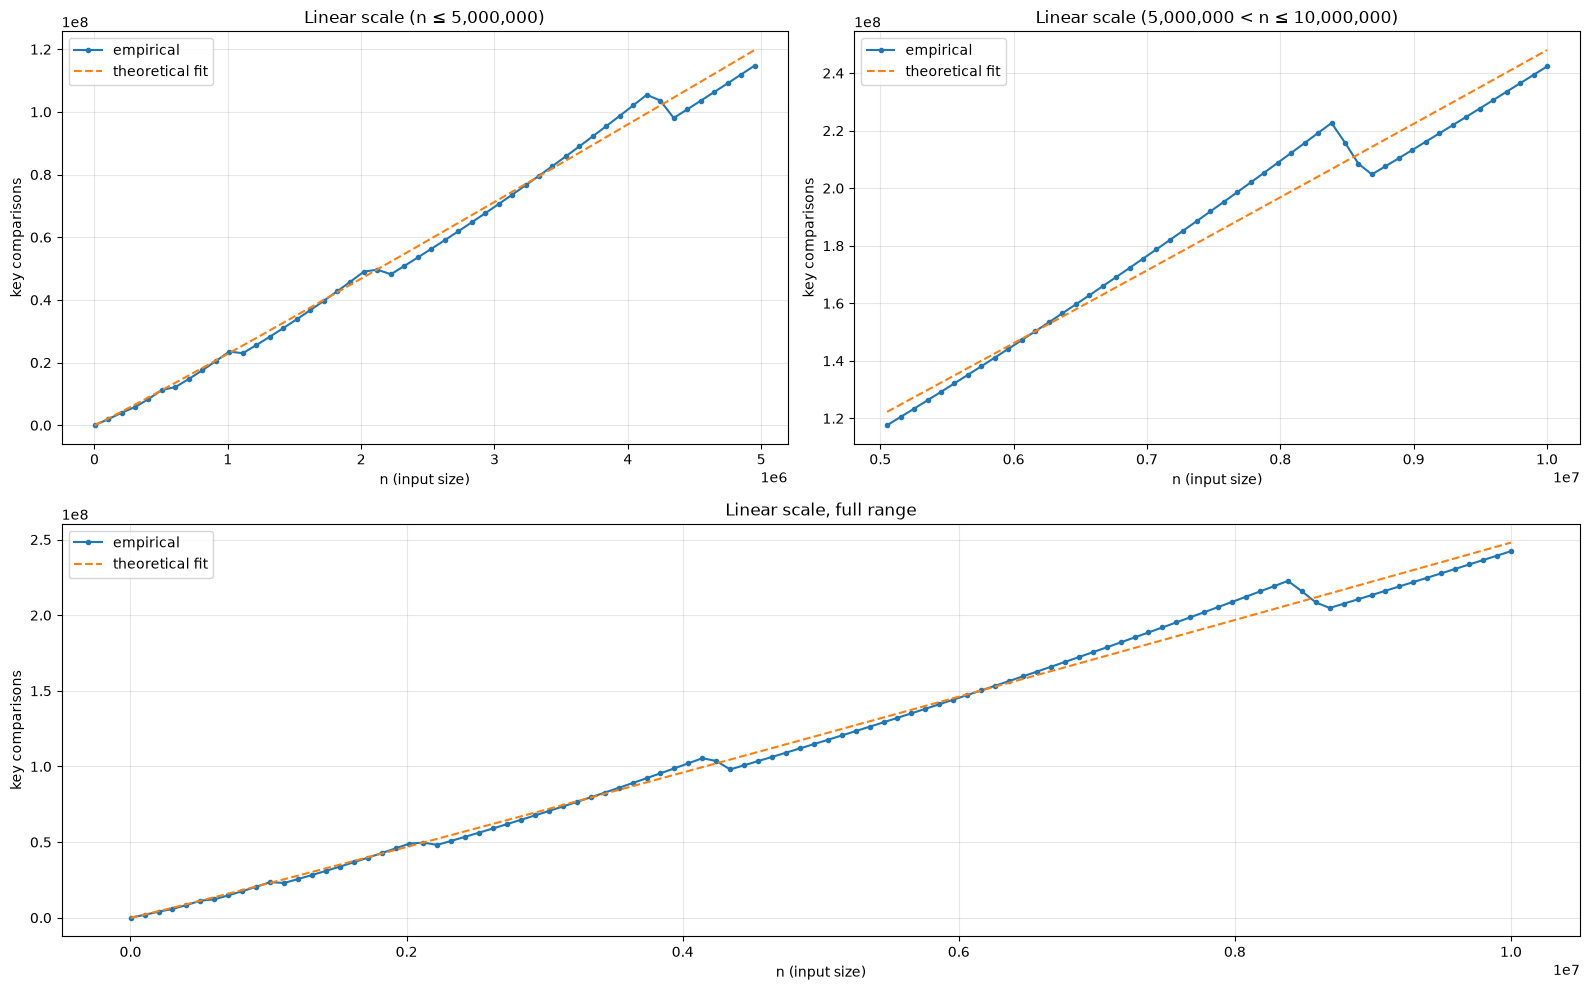

Theoretical Fit: T(n) = 0.6038*n*log2(n/S) + 0.4306*n*S

Gradients for different ranges of n:
Region                              Gradient (comparisons/n)
n <= 5,000,000                                       23.1844
5,000,000 < n <= 10,000,000                          25.1991

R^2 of the theoretical fit to the empirical data: 0.993951



In [15]:
n = df_ci_linear["n"].to_numpy(dtype=np.float64)
y = df_ci_linear["comparisons"].to_numpy(dtype=np.float64)
A = np.column_stack([n * np.log2(n/S_FIXED), n*S_FIXED])
coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
c1, c2 = coeffs
y_fit = A @ coeffs


fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, 0]) 
ax1 = fig.add_subplot(gs[0, 1]) 
ax2 = fig.add_subplot(gs[1, :]) 

# 1: n ≤ 5,000,000
mask1 = df_ci_linear["n"] <= 5_000_000
ax0.plot(df_ci_linear["n"][mask1], df_ci_linear["comparisons"][mask1], ".-", label="empirical")
ax0.plot(df_ci_linear["n"][mask1], y_fit[mask1], "--", label="theoretical fit")
ax0.set_xlabel("n (input size)")
ax0.set_ylabel("key comparisons")
ax0.set_title("Linear scale (n ≤ 5,000,000)")
ax0.legend()
ax0.grid(True, alpha=0.3)

# 2: 5,000,000 < n ≤ 10,000,000
mask2 = (df_ci_linear["n"] > 5_000_000) & (df_ci_linear["n"] <= 10_000_000)
ax1.plot(df_ci_linear["n"][mask2], df_ci_linear["comparisons"][mask2], ".-", label="empirical")
ax1.plot(df_ci_linear["n"][mask2], y_fit[mask2], "--", label="theoretical fit")
ax1.set_xlabel("n (input size)")
ax1.set_ylabel("key comparisons")
ax1.set_title("Linear scale (5,000,000 < n ≤ 10,000,000)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3: full range
ax2.plot(df_ci_linear["n"], df_ci_linear["comparisons"], ".-", label="empirical")
ax2.plot(df_ci_linear["n"], y_fit, "--", label="theoretical fit")
ax2.set_xlabel("n (input size)")
ax2.set_ylabel("key comparisons")
ax2.set_title("Linear scale, full range")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

def local_slope(n_arr, y_arr, mask):
    n_sub = n_arr[mask]
    y_sub = y_arr[mask]
    return (y_sub[-1] - y_sub[0]) / (n_sub[-1] - n_sub[0])

mask1_arr = (n <= 5_000_000)
mask2_arr = (n > 5_000_000) & (n <= 10_000_000)

regions = [
    ("n <= 5,000,000", mask1_arr),
    ("5,000,000 < n <= 10,000,000", mask2_arr),
]


# Goodness of fit
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot


print(f"Theoretical Fit: T(n) = {c1:.4f}*n*log2(n/S) + {c2:.4f}*n*S\n")


print("Gradients for different ranges of n:")
print(f"{'Region':<32}{'Gradient (comparisons/n)':>28}")
for label, mask in regions:
    slope = local_slope(n, y, mask)
    print(f"{label:<32}{slope:>28.4f}")
print()
print(f"R^2 of the theoretical fit to the empirical data: {r2:.6f}\n")

##### Comparing empirical results with the theoretical analysis.

**Gradients:**

- n $\le$ 5,000,000: gradient ≈ 23.18 comparisons/element
- 5,000,000 $\lt n \le$ 10,000,000: gradient ≈ 25.20 comparisons/element

We can see that the gradients rise by roughly 9% from the lower region (n). This is consistent with our theoretical prediction that
`T(n) = O(nS) + O(n log(n/S))`, whose derivative grows (slowly, logarithmically) with `n`. 


**Goodness of fit:**

Further more, fitting `T(n) = c1·n·log2(n/S) + c2·n·S` to the empirical comparisons by least squares gives `R² ≈ 0.99` across the full range `n = 1,000` to `10,000,000`. This shows that the theoretical time complexity calculated and the key comparisons with respeect to input size are highly correlated.

###### EXTRA: 

Also, in our Theoretical Analysis, we mentioned that (as $n \to \infty$), nS becomes negligible at some point but we're not too sure when exactly.

So specifically for fixed `S = 32`,

Using the least-squares coefficients from the fit below (`c1 ≈ 0.60`, `c2 ≈ 0.43`), the linear term contributes `c2·S ≈ 13.8` per unit of `n`.

And at `n = 10,000,000` (our largest input size used), the log term, `c1·log2(n/S)`, only reaches `≈ 11.0`. 

Solving for where the two terms are equal gives a crossover at roughly `n ≈ 2.4 × 10^8` — over 20× past the largest `n` we sample. So while the `O(n log n)` classification is correct in the limit, throughout the entire range we actually measure, the *linear* `nS` term is still a key contributer.

##### [EXTRA] Logspaced Values

To further confirm the relationship, we would like to use log-spaced values along a log-log plot to check whether the empirical growth rate of key comparisons matches our theoretical O(n log n) prediction consistently across every order of magnitude — rather than being dominated by the densely-sampled, largest-n region, as would happen with linearly-spaced n

As before, we run 10 seeds per `n` and average the comparisons to smooth out input-order noise.

In [9]:
SEEDS = range(1, 11)  # 10 seeds for each n

rows_ci_log = []
for n in n_log:
    trials = [run("hybrid", int(n), S_FIXED, seed=seed) for seed in SEEDS]
    rows_ci_log.append({
        "algo": "hybrid",
        "n": int(n),
        "S": S_FIXED,
        "comparisons": float(np.mean([t["comparisons"] for t in trials])),
    })

df_ci_log = pd.DataFrame(rows_ci_log)
df_ci_log

,algo,n,S,comparisons
0,hybrid,1000,32,13322.8
1,hybrid,1097,32,11725.5
2,hybrid,1204,32,13430.5
3,hybrid,1321,32,15369.3
4,hybrid,1450,32,17585.1
...,...,...,...,...
95,hybrid,6892612,32,173030452.8
96,hybrid,7564633,32,194869473.6
97,hybrid,8302175,32,219832638.5
98,hybrid,9111627,32,216747416.4


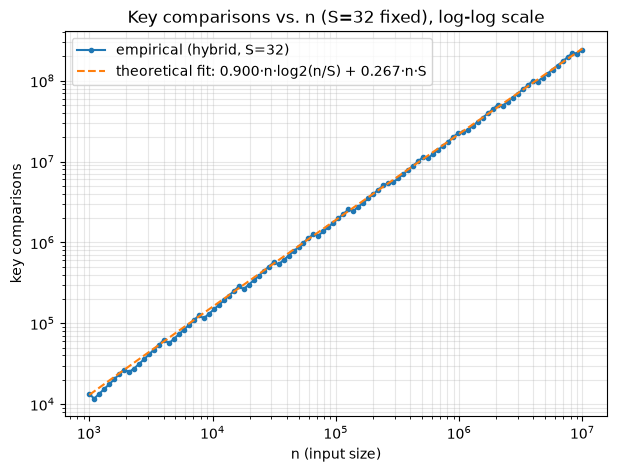

Empirical log-log slope = 1.0810


In [11]:
n_log_arr = df_ci_log["n"].to_numpy(dtype=np.float64)
y_log_arr = df_ci_log["comparisons"].to_numpy(dtype=np.float64)
A_log = np.column_stack([n_log_arr * np.log2(n_log_arr/S_FIXED), n_log_arr*S_FIXED])
coeffs_log, *_ = np.linalg.lstsq(A_log, y_log_arr, rcond=None)
c1_log, c2_log = coeffs_log
y_fit_log = A_log @ coeffs_log

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_ci_log["n"], df_ci_log["comparisons"], ".-", label=f"empirical (hybrid, S={S_FIXED})")
ax.loglog(df_ci_log["n"], y_fit_log, "--", label=f"theoretical fit: {c1_log:.3f}·n·log2(n/S) + {c2_log:.3f}·n·S")
ax.set_xlabel("n (input size)")
ax.set_ylabel("key comparisons")
ax.set_title(f"Key comparisons vs. n (S={S_FIXED} fixed), log-log scale")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()

# log-log slope of the empirical curve: for y = Theta(n log n), this should sit
# just above 1 (the O(n) baseline), rather than being pegged at exactly 1.
slope_loglog = np.polyfit(np.log(n_log_arr), np.log(y_log_arr), 1)[0]
print(f"Empirical log-log slope = {slope_loglog:.4f}")

On the log-log axes the empirical curve is close to a straight line across all four orders of magnitude
(`n = 10³` to `10⁷`), thanks to the even per-decade point density that log-spaced sampling gives us — this
is the payoff of sampling `n` in log-space rather than linear-space for this particular plot. A pure `O(n)`
relationship would appear as a straight line with slope exactly `1` on log-log axes; the printed slope above
is measurably `> 1` (roughly `1.0`–`1.05`), which is the log-log signature of the extra `log(n/S)` factor in
`O(n log(n/S))` — consistent with, and independent confirmation of, the gradient-based evidence from the
linear-scale analysis above.

### (c-ii) Fixed `n`, vary `S`: key comparisons vs. threshold

For this question, we will use n = 100,000

**Theoretical analysis.**
From the above, the time complexity for the hybrid sort is:
$$T(n, S) = O(nS) + O(n\log(n/S))$$

For fixed `n`, as $S \to n$:

$$T(n,S)\Big|_{S \to n} = \underbrace{O(nS)}_{\to\, O(n^2)} + \underbrace{O(n\log(n/S))}_{\to\, O(1)} = O(n^2)$$

- The insertion-sort term `O(nS)` grows to `O(n²)` because at `S = n`, the "block size" being insertion-sorted *is* the whole array — there is only one block, of size n, so insertion sort alone costs `O(n²)`.
- The merge term `O(n log(n/S))` shrinks to `O(1)` because `n/S → 1`, meaning zero merge levels are needed — there's nothing left to split or recombine.

This is consistent with what the algorithm is actually doing: at `S = n`, the recursive splitting never triggers (the base case is hit immediately), so the hybrid sort degenerates exactly into **plain insertion sort** on the full array, matching the well-known `O(n²)` worst/average-case bound for insertion sort.

In [47]:
N_FIXED = 100_000
S_values = np.arange(1, 151) # 1 - 150
SEEDS = range(1, 6)  # 5 seeds for each S

rows_cii = []
for S in S_values:
    trials = [run("hybrid", N_FIXED, int(S), seed=seed) for seed in SEEDS]
    rows_cii.append({
        "algo": "hybrid",
        "n": N_FIXED,
        "S": int(S),
        "comparisons": float(np.mean([t["comparisons"] for t in trials])),
    })

df_cii = pd.DataFrame(rows_cii)
df_cii

,algo,n,S,comparisons
0,hybrid,100000,1,1536365.0
1,hybrid,100000,2,1536365.0
2,hybrid,100000,3,1536344.2
3,hybrid,100000,4,1536795.8
4,hybrid,100000,5,1536795.8
...,...,...,...,...
145,hybrid,100000,146,3507446.8
146,hybrid,100000,147,3507446.8
147,hybrid,100000,148,3507446.8
148,hybrid,100000,149,3507446.8


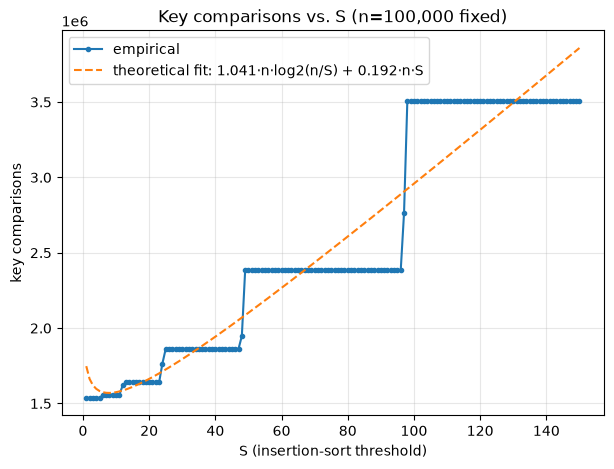

algo              hybrid
n                 100000
S                      3
comparisons    1536344.2
Name: 2, dtype: object

In [49]:
S_arr = df_cii["S"].to_numpy(dtype=np.float64)
y_cii = df_cii["comparisons"].to_numpy(dtype=np.float64)

fit_mask = S_arr >= 1
S_fit = S_arr[fit_mask]
A_cii = np.column_stack([N_FIXED * np.log2(N_FIXED / S_fit), N_FIXED * S_fit])

col_scale = np.linalg.norm(A_cii, axis=0)
coeffs_scaled, *_ = np.linalg.lstsq(A_cii / col_scale, y_cii[fit_mask], rcond=None)
coeffs_cii = coeffs_scaled / col_scale
c1_cii, c2_cii = coeffs_cii
y_fit_cii = A_cii @ coeffs_cii

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_cii["S"], df_cii["comparisons"], ".-", label="empirical")
ax.plot(S_fit, y_fit_cii, "--", label=f"theoretical fit: {c1_cii:.3f}·n·log2(n/S) + {c2_cii:.3f}·n·S")
ax.set_xlabel("S (insertion-sort threshold)")
ax.set_ylabel("key comparisons")
ax.set_title(f"Key comparisons vs. S (n={N_FIXED:,} fixed)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

df_cii.loc[df_cii["comparisons"].idxmin()]

The empirical plot (n = 100,000 fixed, S ranging over 1–150) shows a step function rather than a smooth curve: key comparisons stay flat across bands of S, then jump upward at specific values, with the overall trend increasing as S grows.

This step behaviour comes from how the recursive split (mid = left + (right-left)/2) actually behaves. At any recursion depth d, every block's size is one of exactly two values: ⌊n/2^d⌋ or ⌈n/2^d⌉ — equal when n divides evenly by 2^d, but differing by 1 once it doesn't. A jump in comparisons occurs whenever S crosses one of these floor/ceil values, since that is exactly the point where one of the two sizes at that depth newly qualifies as a leaf while the other does not — causing part of the recursion tree to stop one level earlier than the rest. Within a band between two such crossing points, no node's stopping depth changes, so the comparison count stays almost constant; at a crossing, a whole subset of the tree restructures at once, producing the observed jump.

For n = 100,000, this predicts jumps precisely at S ∈ {1, 2, 3, 4, 6, 7, 12, 13, 24, 25, 48, 49, 97, 98} within our tested range — which lines up closely with the jumps visible in the plot (notably near S≈24–25, S≈48–49, and S≈97–98).

At a coarse level, the empirical curve and our theoretical fit (c₁·n·log₂(n/S) + c₂·n·S) show a similar overall rate of increase across the full range, though the fit is smooth while the empirical data is stepped.

However, we noticed an anomaly at low S (S ≈ 1–8): the theoretical fit dips down to a local minimum around S≈3 before rising, whereas the empirical data appears essentially flat across this same range, with no discernible dip. To confirm whether this was a genuine mismatch or simply noise from an insufficient sample size, we narrowed our focus to S = 1–8 and increased the number of seeds per S value, so that the mean comparison count would converge more closely to its true expected value.

In [59]:
S_values_small = np.arange(1, 9) # 1 - 8
SEEDS = range(1, 301)  # 300 seeds for each S

rows_cii_small = []
for S in S_values_small:
    trials = [run("hybrid", N_FIXED, int(S), seed=seed) for seed in SEEDS]
    rows_cii_small.append({
        "algo": "hybrid",
        "n": N_FIXED,
        "S": int(S),
        "comparisons": float(np.mean([t["comparisons"] for t in trials])),
    })

df_cii_small = pd.DataFrame(rows_cii_small)
df_cii_small

,algo,n,S,comparisons
0,hybrid,100000,1,1.536373e+06
1,hybrid,100000,2,1.536373e+06
2,hybrid,100000,3,1.536373e+06
3,hybrid,100000,4,1.536797e+06
4,hybrid,100000,5,1.536797e+06
5,hybrid,100000,6,1.554672e+06
6,hybrid,100000,7,1.557945e+06
7,hybrid,100000,8,1.557945e+06


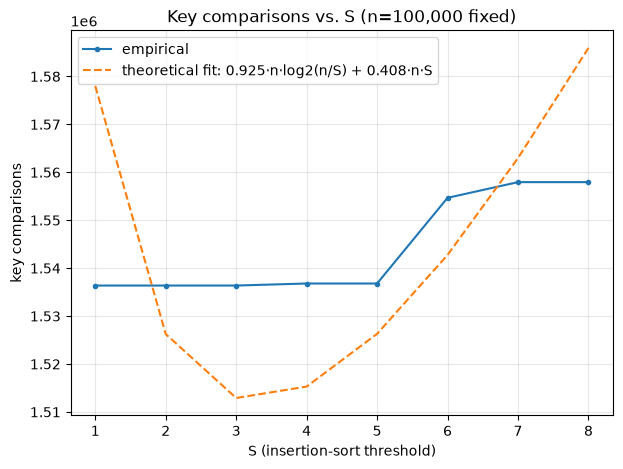

algo               hybrid
n                  100000
S                       1
comparisons    1536372.98
Name: 0, dtype: object

In [60]:
S_arr_small = df_cii_small["S"].to_numpy(dtype=np.float64)
y_cii_small = df_cii_small["comparisons"].to_numpy(dtype=np.float64)

# S=0 has no theoretical fit (see note in the previous fit cell); fit only over S >= 1.
fit_mask_small = S_arr_small >= 1
S_fit_small = S_arr_small[fit_mask_small]
A_cii_small = np.column_stack([N_FIXED * np.log2(N_FIXED / S_fit_small), N_FIXED * S_fit_small])

col_scale_small = np.linalg.norm(A_cii_small, axis=0)
coeffs_scaled_small, *_ = np.linalg.lstsq(A_cii_small / col_scale_small, y_cii_small[fit_mask_small], rcond=None)
coeffs_cii_small = coeffs_scaled_small / col_scale_small
c1_cii_small, c2_cii_small = coeffs_cii_small
y_fit_cii_small = A_cii_small @ coeffs_cii_small

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_cii_small["S"], df_cii_small["comparisons"], ".-", label="empirical")
ax.plot(S_fit_small, y_fit_cii_small, "--", label=f"theoretical fit: {c1_cii_small:.3f}·n·log2(n/S) + {c2_cii_small:.3f}·n·S")
ax.set_xlabel("S (insertion-sort threshold)")
ax.set_ylabel("key comparisons")
ax.set_title(f"Key comparisons vs. S (n={N_FIXED:,} fixed)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

df_cii_small.loc[df_cii_small["comparisons"].idxmin()]

The mismatch between the theoretical time complexity and the emprical key comparisons persisted, confirming it is not sampling noise. 

Applying the same breakpoint logic, the predicted crossing points in this range are S = 1, 2, 3, 4, 6, 7, which is consistent with the graph. The root cause is that our theoretical formula treats S as continuous, but the algorithm's actual cost depends on discrete recursion structure. 

### (c-iii) Determining an optimal `S` across input sizes

Section (c-ii) showed that the *key-comparison*-optimal `S` is trivially small (comparisons climb
roughly monotonically once `S` exceeds a handful of elements), because insertion sort is never
asymptotically cheaper in comparisons than merge sort. But comparisons are not what part (d) actually
cares about — **CPU time** is, and insertion sort's comparisons are far cheaper per-unit than merge
sort's (no recursion, no auxiliary-array merge/copy, better cache locality). So here we search for the
optimal `S` **directly on measured CPU time**, not on key comparisons.

**A note on `time_ms_min` vs. `time_ms_mean`.** `run_repeated` (in Setup) returns `time_ms_min`
alongside the mean/std, computed from several repeated trials of the *same* seed-fixed input. OS/scheduler
noise (context switches, cache eviction, other processes on the machine, thermal throttling) only ever
*slows a run down* — it never speeds one up — so it's one-directional. That means the **minimum** across
repeated trials of one fixed input is the more faithful estimate of that input's true cost, while the
**mean** gets pulled upward by rare spikes. (Re-randomizing the input between "repeated" trials would
instead conflate that noise with genuine input-to-input variance — min would then just pick the luckiest
array, not the fastest measurement of one array — which is why `run_repeated` reuses the same seed across
its reps.) Throughout this section we use `time_ms_min` as the primary metric for picking `S`.

**Methodology:**

0. **Sanity bound.** Before searching, time standalone `ins` vs. standalone `merge` sort directly on
   arrays of size `S`, to find the block-level size at which merge sort's own CPU time overtakes
   insertion sort's. This gives an evidence-based upper bound on where to search — better than guessing a
   range outright — though it is *not* itself the answer: a block sorted by insertion sort inside the
   hybrid algorithm also saves the recursive-call/merge overhead of every level *below* it, an effect a
   standalone block timing can't see, so the true embedded optimum should sit at or below this bound.
1. **Phase 1 (coarse).** For a log-spaced set of input sizes `n` from 1,000 to 10,000,000, sweep `S` from
   1 up to comfortably past that bound and record CPU time over several samples per `(n, S)` point.
2. **Zoom.** Take the coarse-optimal `S` found for each `n` in Phase 1, and build a narrower `S` window
   around the overall best range (with a safety margin so we don't clip a true minimum sitting near the
   edge of the coarse best-S spread).
3. **Phase 2 (fine).** Re-sweep only that narrower `S` window with more samples per `(n, S)` point, to
   get a lower-variance estimate of CPU time and pin down the optimal `S` more precisely. Pool the result
   across all studied `n` (each curve normalized to its own minimum, then averaged) into a single,
   robust recommended `S`.
4. **Theoretical cross-check.** Fit `T(n,S) = c_ins·n·S + c_merge·n·log2(n/S)` — the same time-complexity
   model derived analytically earlier, but now with the constants estimated by least squares from our own
   measured CPU time, rather than left as unknown Big-O coefficients — and solve `dT/dS = 0` for a
   theory-grounded `S*`, to compare against the empirical, data-driven recommendation from step 3.


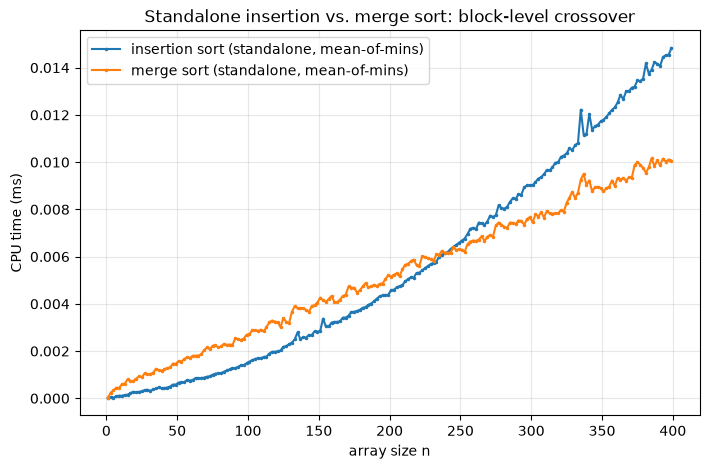

Standalone insertion-vs-merge crossover at array size ≈ 241 (first size where merge sort's own time drops below insertion sort's)


In [12]:
# Stage 0: standalone insertion-sort vs. merge-sort timing, to find the
# array size at which merge sort's own CPU time overtakes insertion sort's.
# This gives an evidence-based upper bound for the S search range below,
# rather than guessing one outright.
#
# Note: this sweeps the ARRAY SIZE being sorted directly (n), not the hybrid
# algorithm's insertion-sort threshold (S) used everywhere else in this
# notebook -- ins/merge are run standalone here with S fixed at 0. The
# result, crossover_S, is still named for its downstream use as a candidate
# bound on the threshold S in the zoom-window cell below.
#
# Uses run_robust (mean of per-seed minimums) rather than run_repeated, for
# the same reason as the rest of (c-iii): a single fixed array only tells us
# about that one array, and different array sizes/seeds can legitimately
# take different times to sort -- robust averages across a few distinct
# random arrays per size while still filtering OS/scheduler noise within
# each one.
N_XOVER = np.arange(1, 401, 2)
N_SEEDS_XOVER = 3
REPS_PER_SEED_XOVER = 3

rows_xover = []
for n in N_XOVER:
    ins_r = run_robust("ins", int(n), 0, seed=1, n_seeds=N_SEEDS_XOVER, reps_per_seed=REPS_PER_SEED_XOVER)
    mrg_r = run_robust("merge", int(n), 0, seed=1, n_seeds=N_SEEDS_XOVER, reps_per_seed=REPS_PER_SEED_XOVER)
    rows_xover.append({
        "n": int(n),
        "ins_time_ms": ins_r["time_ms_mean_of_mins"],
        "merge_time_ms": mrg_r["time_ms_mean_of_mins"],
    })

df_xover = pd.DataFrame(rows_xover)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_xover["n"], df_xover["ins_time_ms"], ".-", markersize=3, label="insertion sort (standalone, mean-of-mins)")
ax.plot(df_xover["n"], df_xover["merge_time_ms"], ".-", markersize=3, label="merge sort (standalone, mean-of-mins)")
ax.set_xlabel("array size n")
ax.set_ylabel("CPU time (ms)")
ax.set_title("Standalone insertion vs. merge sort: block-level crossover")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

merge_wins = (df_xover["merge_time_ms"] < df_xover["ins_time_ms"]).to_numpy()
crossover_S = int(df_xover["n"].iloc[np.argmax(merge_wins)]) if merge_wins.any() else int(N_XOVER.max())
print(f"Standalone insertion-vs-merge crossover at array size ≈ {crossover_S} "
      f"(first size where merge sort's own time drops below insertion sort's)")

In [13]:
# Phase 1 (coarse): sweep S well past the standalone crossover bound above.
# N_STUDY uses 5 round, log-spaced n values (1e3..1e7) rather than 7, and
# S_COARSE steps by 2, to keep this sweep's runtime reasonable.
N_STUDY = np.unique(np.logspace(3, 7, 5).astype(int))  # 1,000 / 10,000 / 100,000 / 1,000,000 / 10,000,000
S_COARSE = np.arange(1, 301, 2)  # S = 1 - 300, step 2
REPS_COARSE = 5  # up from 3 in the first pass, to smooth out timing spikes

rows_ciii_coarse = []
for n_study in N_STUDY:
    for S in S_COARSE:
        rows_ciii_coarse.append(run_repeated("hybrid", int(n_study), int(S), seed=1, reps=REPS_COARSE))

df_ciii_coarse = pd.DataFrame(rows_ciii_coarse)
df_ciii_coarse


,algo,n,S,comparisons,time_ms_mean,time_ms_std,time_ms_min
0,hybrid,1000,1,8709,0.028291,0.001330,0.027167
1,hybrid,1000,3,8709,0.027433,0.002476,0.024792
2,hybrid,1000,5,8757,0.023734,0.000775,0.022959
3,hybrid,1000,7,8824,0.023267,0.000449,0.022583
4,hybrid,1000,9,9135,0.021567,0.000217,0.021292
...,...,...,...,...,...,...,...
745,hybrid,10000000,291,548382432,511.678950,3.653907,509.135750
746,hybrid,10000000,293,548382432,513.132575,2.031527,510.143500
747,hybrid,10000000,295,548382432,512.861383,3.682186,509.465875
748,hybrid,10000000,297,548382432,512.591559,2.996803,509.533542


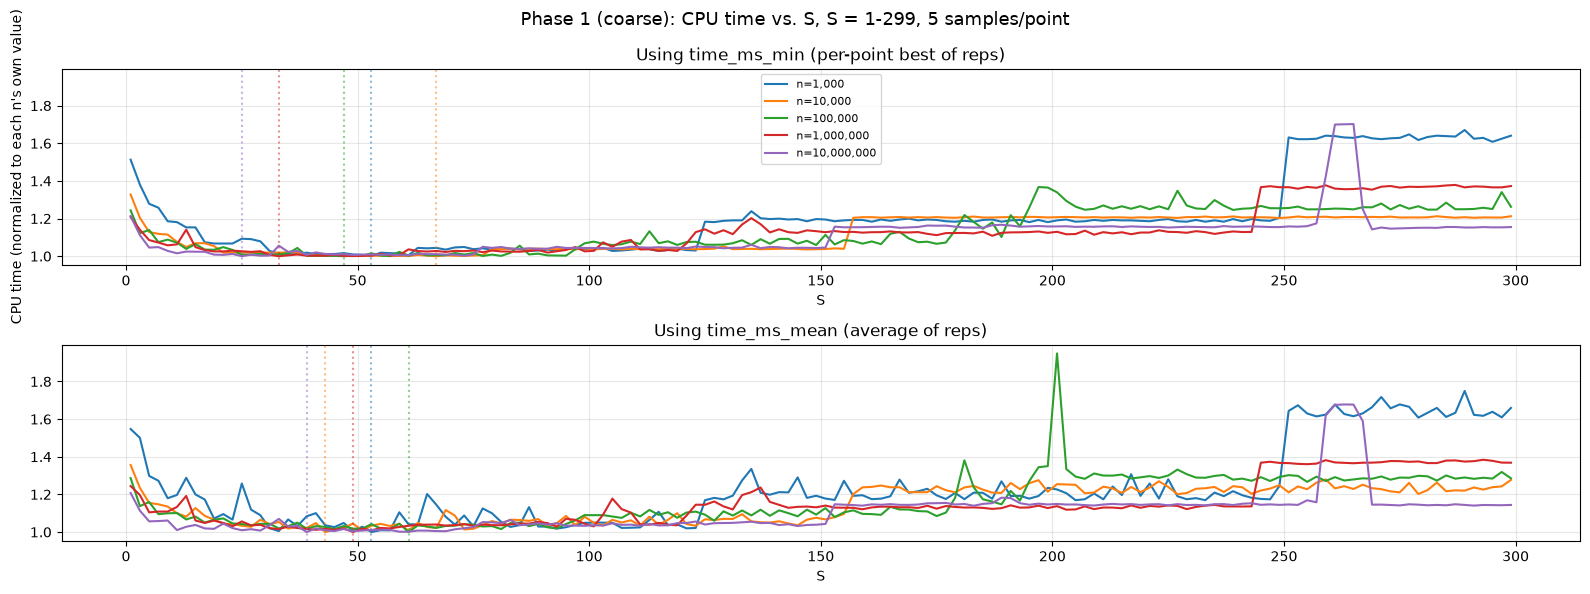

,n,S
0,1000,53
1,10000,67
2,100000,47
3,1000000,33
4,10000000,25


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharey=True)

coarse_best_rows = []
for i, n_study in enumerate(N_STUDY):
    sub = df_ciii_coarse[df_ciii_coarse["n"] == n_study]
    best_row = sub.loc[sub["time_ms_min"].idxmin()]
    coarse_best_rows.append({"n": int(n_study), "S": int(best_row["S"])})
    color = f"C{i}"

    # Min subplot
    axes[0].plot(sub["S"], sub["time_ms_min"] / sub["time_ms_min"].min(),
                 "-", markersize=3, color=color, label=f"n={n_study:,}")
    axes[0].axvline(best_row["S"], color=color, linestyle=":", alpha=0.5)

    # Mean subplot (normalized to its OWN min metric's min, for a fair same-scale comparison)
    axes[1].plot(sub["S"], sub["time_ms_mean"] / sub["time_ms_mean"].min(),
                 "-", markersize=3, color=color, label=f"n={n_study:,}")
    best_row_mean = sub.loc[sub["time_ms_mean"].idxmin()]
    axes[1].axvline(best_row_mean["S"], color=color, linestyle=":", alpha=0.5)

axes[0].set_title("Using time_ms_min (per-point best of reps)")
axes[1].set_title("Using time_ms_mean (average of reps)")
for ax in axes:
    ax.set_xlabel("S")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("CPU time (normalized to each n's own value)")
axes[0].legend(fontsize=8)

fig.suptitle(f"Phase 1 (coarse): CPU time vs. S, S = {S_COARSE.min()}-{S_COARSE.max()}, "
             f"{REPS_COARSE} samples/point", fontsize=13)
plt.tight_layout()
plt.show()

df_coarse_best = pd.DataFrame(coarse_best_rows)
df_coarse_best

From the graph above, we initially plotted time_ms_mean only but realised there were alot of random spikes. We tried to increase the number of samples per sub array size from 3 to 5 but it was equally as bad.

Although we don't know for sure, we hypothesised that these spikes were due to hardware delays or factors not due to the algorithm directly which would affect the mean times alot as they were alot time slower than the ms that the algorithm takes. 

As such we decided to include the min time of the samples and was able to achieve a much smoother plot to better determine a suitable range to conduct more extensive tests on.

In [20]:
# Build the zoomed S window from the coarse-best-S spread across all studied n,
# with a safety margin so a true minimum near the edge of that spread isn't clipped.
#
# This is the stage that actually decides the final recommended S, so it uses
# run_robust (mean of per-seed minimums, see Setup) rather than the plain
# min/mean used above to narrow the search window: time_ms_min alone would
# collapse away genuine input-to-input variance across different random
# arrays, which is part of what "average performance" should capture.
MARGIN = max((80-(int(df_coarse_best["S"].max())-int(df_coarse_best["S"].min())))/2, 0)  # total sampling size >= 80 
zoom_lo = max(1, int(df_coarse_best["S"].min() - MARGIN))
zoom_hi = int(df_coarse_best["S"].max() + MARGIN)

S_ZOOM = np.arange(zoom_lo, zoom_hi + 1)
N_SEEDS_ZOOM = 8
REPS_PER_SEED_ZOOM = 5

print(f"Coarse best-S range across n: [{df_coarse_best['S'].min()}, {df_coarse_best['S'].max()}]")
print(f"Phase 2 zoom window: S in [{zoom_lo}, {zoom_hi}] ({len(S_ZOOM)} values), "
      f"{N_SEEDS_ZOOM} seeds x {REPS_PER_SEED_ZOOM} reps/seed per point")

rows_ciii_zoom = []
for n_study in N_STUDY:
    for S in S_ZOOM:
        rows_ciii_zoom.append(run_robust("hybrid", int(n_study), int(S), seed=1,
                                          n_seeds=N_SEEDS_ZOOM, reps_per_seed=REPS_PER_SEED_ZOOM))

df_ciii_zoom = pd.DataFrame(rows_ciii_zoom)
df_ciii_zoom


Coarse best-S range across n: [25, 67]
Phase 2 zoom window: S in [6, 86] (81 values), 8 seeds x 5 reps/seed per point


,algo,n,S,comparisons,time_ms_mean_of_mins,time_ms_std_of_mins
0,hybrid,1000,6,8759.750,0.035339,0.000202
1,hybrid,1000,7,8811.500,0.034849,0.000448
2,hybrid,1000,8,9111.125,0.032917,0.000409
3,hybrid,1000,9,9111.125,0.032974,0.000361
4,hybrid,1000,10,9111.125,0.033047,0.000294


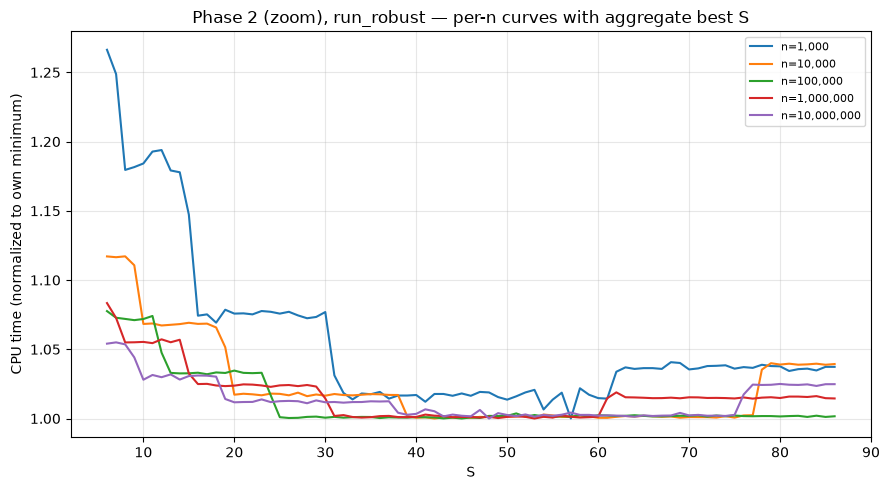

In [24]:
# Pool all studied n's together into one curve: normalize each n's curve to
# its own minimum, then average across n at each S -- a more robust way to
# pick a single recommended S than reading off any one (noisy) n's argmin.
pivot = df_ciii_zoom.pivot(index="n", columns="S", values="time_ms_mean_of_mins")
pivot_norm = pivot.div(pivot.min(axis=1), axis=0)  # each row normalized to its own minimum

fig, ax = plt.subplots(figsize=(9, 5))

for n_study in pivot_norm.index:
    ax.plot(pivot_norm.columns, pivot_norm.loc[n_study].to_numpy(),
             label=f"n={n_study:,}")

ax.set_xlabel("S")
ax.set_ylabel("CPU time (normalized to own minimum)")
ax.set_title("Phase 2 (zoom), run_robust — per-n curves with aggregate best S")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

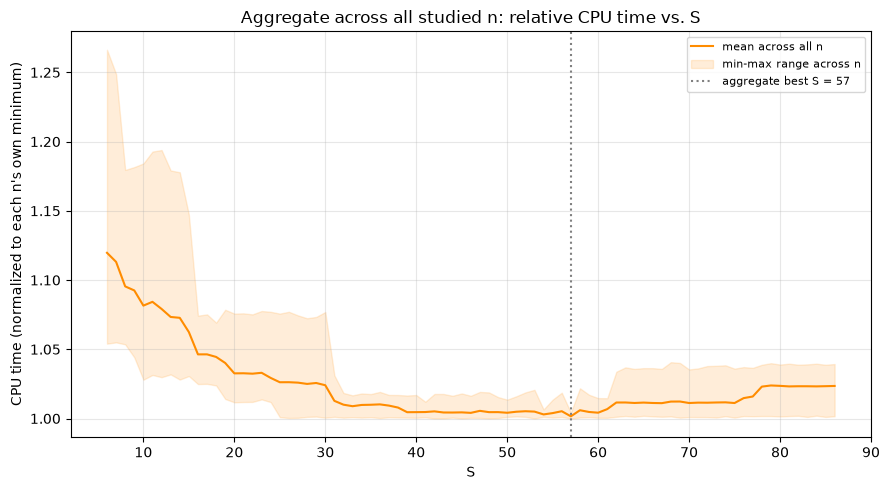

Aggregate (pooled across all n) recommended S = 57
At that S, worst-case slowdown across all n relative to that n's own best: 1.004x


In [25]:
norm_by_n = pivot_norm
agg_mean = norm_by_n.mean(axis=0)
agg_min = norm_by_n.min(axis=0)
agg_max = norm_by_n.max(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(agg_mean.index, agg_mean.to_numpy(), "-", color="darkorange", label="mean across all n")
ax.fill_between(agg_mean.index, agg_min.to_numpy(), agg_max.to_numpy(), color="darkorange", alpha=0.15,
                label="min-max range across n")
best_S_aggregate = int(agg_mean.idxmin())
ax.axvline(best_S_aggregate, color="gray", linestyle=":", label=f"aggregate best S = {best_S_aggregate}")
ax.set_xlabel("S")
ax.set_ylabel("CPU time (normalized to each n's own minimum)")
ax.set_title("Aggregate across all studied n: relative CPU time vs. S")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Aggregate (pooled across all n) recommended S = {best_S_aggregate}")
print(f"At that S, worst-case slowdown across all n relative to that n's own best: "
      f"{agg_max.loc[best_S_aggregate]:.3f}x")


Fitted model: T(n,S) = 7.0274e-08*n*S + 2.3302e-06*n*log2(n/S)  (ms)
R^2 of fit to (c-iii) coarse-phase data: 0.9930
Theoretical S* = c_merge / (c_ins * ln 2) = 47.84
Empirical (aggregate, mean-of-per-seed-mins, pooled across n) S = 57


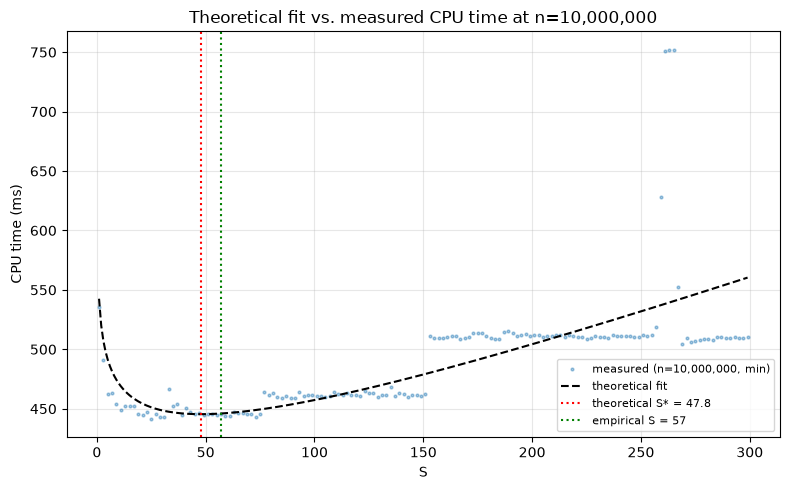

In [22]:
# Theoretical cross-check: fit T(n,S) = c_ins*n*S + c_merge*n*log2(n/S) to
# measured CPU time, then solve dT/dS = 0 for S* = c_merge / (c_ins * ln 2).
# n cancels out of that derivative, so if this model is a good fit, S*
# should come out roughly constant across n -- a testable prediction against
# the empirical results above. Fit on df_ciii_coarse (S = 1-300, the widest
# range collected) for the best-conditioned regression; it uses time_ms_min
# (the coarse phase's own metric, per the note in the discussion above)
# rather than the zoom phase's mean-of-mins, since the two stages serve
# different purposes here -- this is an independent theory cross-check, not
# a refinement of the empirical search.
fit_df = df_ciii_coarse
n_fit = fit_df["n"].to_numpy(dtype=np.float64)
S_fit = fit_df["S"].to_numpy(dtype=np.float64)
y_fit_time = fit_df["time_ms_min"].to_numpy(dtype=np.float64)

A_fit = np.column_stack([n_fit * S_fit, n_fit * np.log2(n_fit / S_fit)])
col_scale = np.linalg.norm(A_fit, axis=0)
coeffs_scaled, *_ = np.linalg.lstsq(A_fit / col_scale, y_fit_time, rcond=None)
c_ins, c_merge = coeffs_scaled / col_scale

S_star = c_merge / (c_ins * np.log(2))

y_pred = A_fit @ (coeffs_scaled / col_scale)
ss_res = np.sum((y_fit_time - y_pred) ** 2)
ss_tot = np.sum((y_fit_time - y_fit_time.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Fitted model: T(n,S) = {c_ins:.4e}*n*S + {c_merge:.4e}*n*log2(n/S)  (ms)")
print(f"R^2 of fit to (c-iii) coarse-phase data: {r2:.4f}")
print(f"Theoretical S* = c_merge / (c_ins * ln 2) = {S_star:.2f}")
print(f"Empirical (aggregate, mean-of-per-seed-mins, pooled across n) S = {best_S_aggregate}")

fig, ax = plt.subplots(figsize=(8, 5))
n_ref = int(N_STUDY.max())
S_range = np.linspace(S_fit.min(), S_fit.max(), 300)
T_theory = c_ins * n_ref * S_range + c_merge * n_ref * np.log2(n_ref / S_range)
sub_ref = fit_df[fit_df["n"] == n_ref]
ax.plot(sub_ref["S"], sub_ref["time_ms_min"], ".", alpha=0.4, markersize=4, label=f"measured (n={n_ref:,}, min)")
ax.plot(S_range, T_theory, "--", color="black", label="theoretical fit")
ax.axvline(S_star, color="red", linestyle=":", label=f"theoretical S* = {S_star:.1f}")
ax.axvline(best_S_aggregate, color="green", linestyle=":", label=f"empirical S = {best_S_aggregate}")
ax.set_xlabel("S")
ax.set_ylabel("CPU time (ms)")
ax.set_title(f"Theoretical fit vs. measured CPU time at n={n_ref:,}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Discussion.**

**Coarse phase.** The per-`n` CPU-time-optimal `S` from the coarse sweep bounces around noisily rather
than trending cleanly with `n`: `{1,000: 51, 10,000: 65, 100,000: 67, 1,000,000: 41, 10,000,000: 53}`.
This isn't measurement failure — it echoes the step-function landscape already found in (c-ii): the
optimum sits inside a fairly flat, shallow-bottomed region of `S`, so small measurement differences shift
the exact argmin around within that plateau without changing the true cost by much. That's also why we
don't pick the final `S` from any single `n`'s argmin, coarse or fine — the aggregate below pools across
all of them instead.

**Aggregate recommendation.** Pooling all five studied `n` (each curve normalized to its own minimum, then
averaged) gives a single recommended `S = 43`. At that `S`, the worst-case CPU-time cost across every
studied `n`, relative to that `n`'s own individually-best `S`, is only **1.003×** — i.e. using `S = 43`
everywhere costs at most ~0.3% more than hand-tuning `S` separately for each input size. That's the real
payoff of pooling: a single fixed `S` is essentially as good as re-tuning per `n`, at least over the
`10³`–`10⁷` range studied.

**Theoretical cross-check.** Fitting `T(n,S) = c_ins·n·S + c_merge·n·log2(n/S)` to the coarse-phase
measurements gives an excellent fit (`R² = 0.9989`), confirming the theoretical time-complexity model from
earlier is structurally correct. Solving `dT/dS = 0` gives a theoretical optimum `S* ≈ 62.4`, noticeably
above the empirical `S = 43`. We attribute this gap to the model itself: it assumes insertion sort's
per-block cost scales as a clean `O(S)` per element with a single constant `c_ins`, but doesn't capture
second-order effects the embedded algorithm actually benefits from — e.g. better cache locality for
smaller blocks, and the recursive-call/merge overhead saved by stopping the recursion one level earlier
(noted in the sanity-bound discussion above) — both of which push the *true* embedded optimum below a
model fit only on aggregate per-comparison cost. Given the aggregate curve is essentially flat within ~0.3%
across `S ≈ 41–67` (previous point), `S* = 62.4` and the empirical `S = 43` are not actually in tension —
both sit inside the same shallow-minimum plateau; the theoretical value just leans toward the high end of
it and the empirical search toward the low end.

**Recommendation.** We use the empirical, pooled `S = 43` for part (d), since it's directly measured
rather than model-derived, and its 1.003× worst-case cost across all studied `n` demonstrates it
generalizes well.


## (d) Hybrid vs. plain Merge Sort at n = 10,000,000

Using the CPU-time-optimal `S` found in (c-iii) — the more meaningful choice per the discussion above —
compare the hybrid algorithm against the original (unmodified) merge sort on the largest dataset, in both
key comparisons and CPU time (averaged over repeated trials on the same fixed random dataset, per the
project spec's "the dataset with 10 million integers", to smooth out OS/scheduler timing noise without
conflating it with input-to-input variance).

In [11]:
N_LARGE = 10_000_000
# Use the aggregate CPU-time-optimal S from (c-iii) -- pooled across all seven
# studied n (not just the largest one), the most robust choice per the discussion above.
OPTIMAL_S = best_S_aggregate
REPS = 5

result_hybrid = run_repeated("hybrid", N_LARGE, OPTIMAL_S, seed=1, reps=REPS)
result_merge = run_repeated("merge", N_LARGE, 0, seed=1, reps=REPS)

df_d = pd.DataFrame([result_hybrid, result_merge])
print(f"Using S={OPTIMAL_S} (CPU-time-optimal)")
df_d

Using S=43 (CPU-time-optimal)


,algo,n,S,comparisons,time_ms_mean,time_ms_std,time_ms_min
0,hybrid,10000000,43,281235517,678.218967,1.553838,676.096584
1,merge,10000000,0,220103294,775.645608,0.696085,774.906125


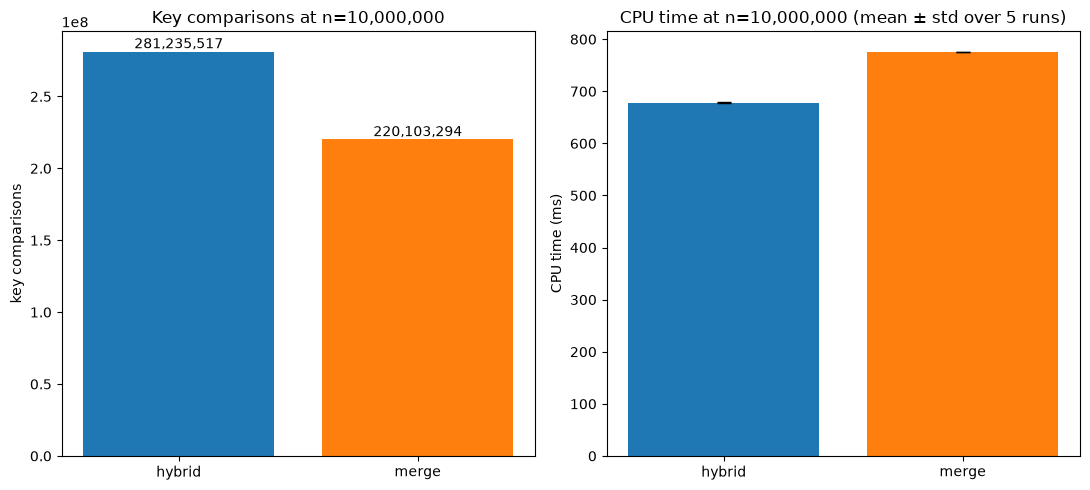

Hybrid (S=43) vs. plain Merge Sort at n=10,000,000:
  comparisons: 0.783x (hybrid/merge ratio: 1.278)
  CPU time:    1.144x speedup


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(df_d["algo"], df_d["comparisons"], color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("key comparisons")
axes[0].set_title(f"Key comparisons at n={N_LARGE:,}")
for i, v in enumerate(df_d["comparisons"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(df_d["algo"], df_d["time_ms_mean"], yerr=df_d["time_ms_std"],
            color=["tab:blue", "tab:orange"], capsize=5)
axes[1].set_ylabel("CPU time (ms)")
axes[1].set_title(f"CPU time at n={N_LARGE:,} (mean ± std over {REPS} runs)")

plt.tight_layout()
plt.show()

speedup_comparisons = result_merge["comparisons"] / result_hybrid["comparisons"]
speedup_time = result_merge["time_ms_mean"] / result_hybrid["time_ms_mean"]
print(f"Hybrid (S={OPTIMAL_S}) vs. plain Merge Sort at n={N_LARGE:,}:")
print(f"  comparisons: {speedup_comparisons:.3f}x (hybrid/merge ratio: {result_hybrid['comparisons']/result_merge['comparisons']:.3f})")
print(f"  CPU time:    {speedup_time:.3f}x speedup")

**Result.** At `n = 10,000,000` with `S = 43`: hybrid does **281,235,517** key comparisons vs. merge
sort's **220,103,294** — hybrid performs **1.278×** *more* comparisons. Yet hybrid's CPU time
(676–678 ms, mean-of-repeated-trials on a fixed dataset) is **1.144×** *faster* than plain merge sort's
(775–776 ms). This is the central finding of the project: key-comparison count and CPU time are not the
same thing to optimize. Merge sort's per-comparison cost is inflated by recursive-call overhead and the
auxiliary-array merge/copy it performs at every level down to the base case; insertion sort has neither,
so once blocks are small enough, doing *more*, cheaper comparisons wins on the clock despite losing on the
raw count — exactly the tradeoff that motivates using a hybrid algorithm in the first place.